This notebook is meant to showcase various versions of HATS-ed catalogs that I am creating for testing purposes.  It contains methods for visualizing those catalogs.

This should be run on Aurora, as the catalogs used are saved on-disk in /net/scratch.

*For Katie: I am using my argvenv kernel to run this.* 

**The catalog in question: ATLAS-Refcat2**

The un-HATS-ed version of ATLAS saved on Aurora in /etc/rico/atlas_refcat2/ is saved in .feather files; see the readme for a full explanation.  

Various versions of ATLAS in HATS format (largely created for testing purposes) are stored in Katie's scratch directory under /net/scratch/kfmas/atlas_refcat2/ and include:
- atlas_0_01: created to test hats-import pipeline
- atlas_0_001: created to test hats-import Import Arguments
- atlas_500files: created for testing Dask setup for full-scale HATS import
- atlas_1000files: created for testing Dask setup for full-scale HATS import
- atlas_hatsed: first attempt at a fully-HATS-ed ATLAS (I will note that Dask workers were removed & restarted several times during the Reducing stage, but the import still finished.)
    - Dask Client setup:
        - 4 workers
        - 1 thread per worker
        - 16GB memory limit per worker
    - hats-import Import Arguments:
        - pixel threshold = 5M (too high, since highest order HEALPix is only 5)
        - lowest-order HEALPix = 2
        - highets-order HEALPix = 12
- atlas_full: second attempt at a fully-HATS-ed ATLAS
    - Dask Client setup:
        - 4 workers
        - 1 thread per worker
        - 20GB memory limit per worker
    - hats-imporot Import Arguments:
        - pixel threshold = 500,000
        - lowest-order HEALPix = 2
        - highetst-order HEALPix = 12



In [1]:
import glob
import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

Just for reference, how many sources are in ATLAS above -20deg Dec?  Check the un-HATS-ed version of ATLAS.

In [10]:
atlas_files = glob.glob("/etc/rico/atlas_refcat2/*/*/*",recursive=True)
n_src_g_n20 = 0
for fl in atlas_files:
    dat = pd.read_feather(fl)
    dat_dec_g_n20 = dat[dat['dec']>-20]
    n_src_g_n20+=len(dat_dec_g_n20)

print(f"{n_src_g_n20} sources in ATLAS-Refcat2 with Dec > -20deg")

450324489 sources in ATLAS-Refcat2 with Dec > -20deg


# Fractional HATS-ed versions of ATLAS-Refcat2

In [4]:
# these cats were HATSed with my import_with_hats_import.py script, with the hats-import package
cat_0_001 = lsdb.open_catalog("/net/scratch/kmfas/atlas_refcat2/atlas_0_001/",filters=[["dec", ">", -20]])
cat_0_01 = lsdb.open_catalog("/net/scratch/kmfas/atlas_refcat2/atlas_0_01/",filters=[["dec", ">", -20]])

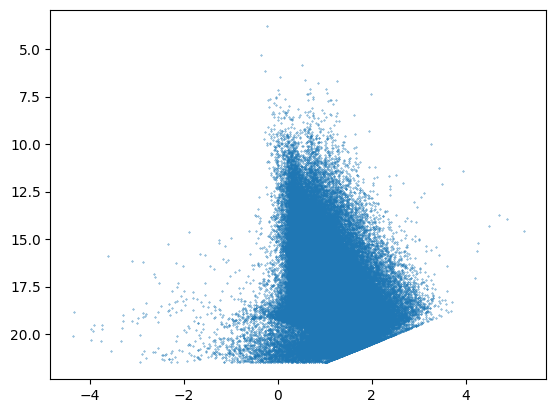

In [ ]:
f,ax = plt.subplots(1)
ax.hist2d(cat_0_001['g']-cat_0_001['r'],cat_0_001['r'],bins=[100,100])
ax.invert_yaxis()
plt.show()

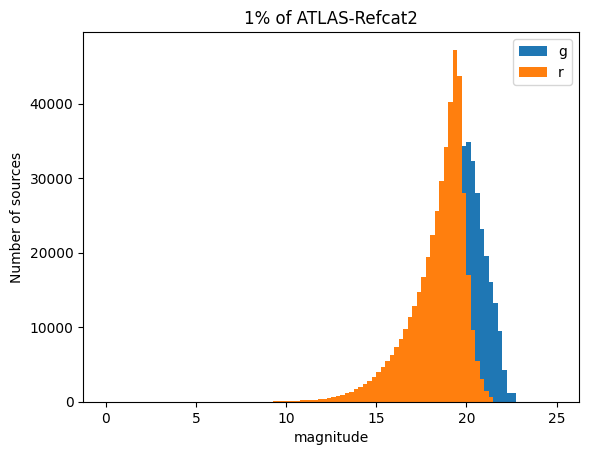

In [ ]:
plt.title(f"1% of ATLAS-Refcat2")
plt.hist(cat_0_001['g'],bins=100,range=[5,25],label="g",facecolor=[0,0,0,0])
plt.hist(cat_0_001['r'],bins=100,range=[5,25],label="r",facecolor=[0,0,0,0])
plt.legend()
plt.xlabel("magnitude")
plt.ylabel("Number of sources")
plt.show()

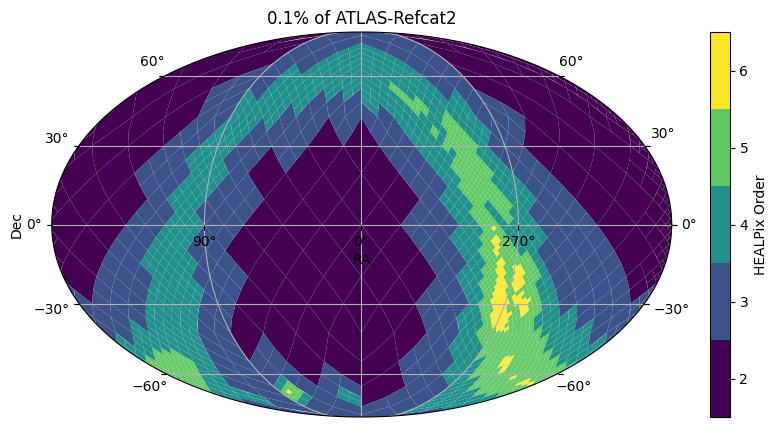

In [8]:
fig,ax = cat_0_001.plot_pixels(plot_title=f"0.1% of ATLAS-Refcat2")
plt.show()

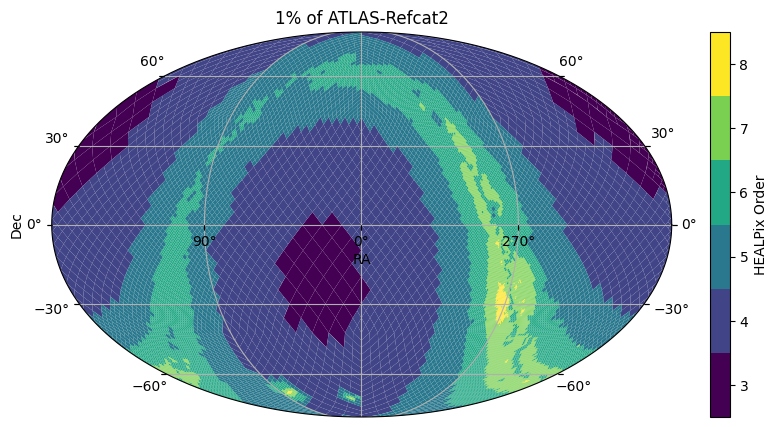

In [9]:
fig,ax = cat.plot_pixels(plot_title=f"1% of ATLAS-Refcat2")
plt.show()

# First fully HATS-ed ATLAS:
import arguments were:
lowest HEALPix order = 2
highest HEALPix order = 12

Dask Client:
4 workers
1 thread per worker
memory limit = 16GB

Outcome: 
lowest HEALPix order = 2
highest HEALPix order = 5


In [4]:
atlas_full = lsdb.open_catalog("/net/scratch/kmfas/atlas_refcat2/atlas_hatsed")

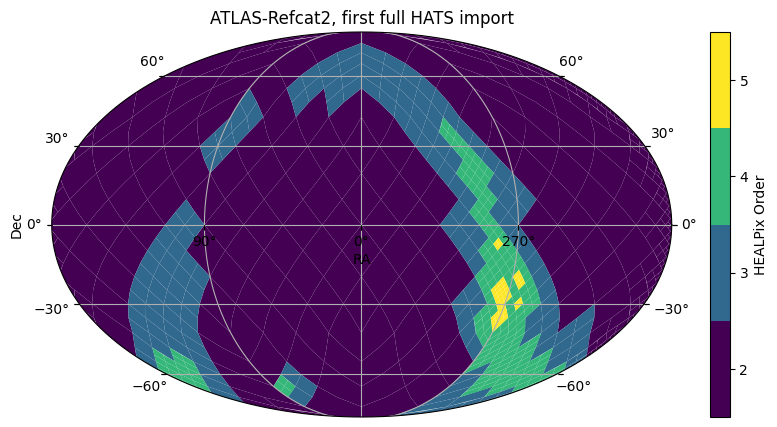

In [3]:
fig,ax = atlas_full.plot_pixels(plot_title="ATLAS-Refcat2, first full HATS import")